<a href="https://colab.research.google.com/github/devikapranesh/Scafolded-Project_DL/blob/main/Updated_MLP_%26CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Updated Scaffolded Project with HAR Dataset**

# Task
Document the provided Colab notebook by adding text cells to introduce the Human Activity Recognition project and the UCI HAR Dataset, explain the imported libraries, detail the data loading and preprocessing steps (including unzipping "UCI HAR Dataset.zip" and handling scaling/one-hot encoding), describe the architecture, training, and evaluation of both the Multi-Layer Perceptron (MLP) and Convolutional Neural Network (CNN) models (including CNN data reshaping), explain the confusion matrix and accuracy plots for the CNN, compare the accuracies of the MLP and CNN models, and clarify the hyperparameter experiment results table.

## Project Introduction

This project focuses on **Human Activity Recognition (HAR)**, a machine learning task that aims to classify human activities based on sensor data. The primary objective is to develop and evaluate models capable of accurately identifying different physical activities performed by individuals.

We will be utilizing the **UCI HAR Dataset**, which contains sensor data collected from smartphones worn by 30 subjects. The dataset captures 6 different activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING) using accelerometer and gyroscope readings. This data will be used to train and test our models for activity classification.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
from google.colab import files
uploaded = files.upload()

Saving UCI HAR Dataset.zip to UCI HAR Dataset.zip


## Data Loading and Preprocessing Documentation

### Subtask:
Steps involved in loading the dataset, unzipping it, and preprocessing the data.


In [6]:
import zipfile

with zipfile.ZipFile("/content/UCI HAR Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

import os
os.listdir('/content/UCI HAR Dataset')

['train',
 'activity_labels.txt',
 'features.txt',
 'test',
 '.DS_Store',
 'README.txt',
 'features_info.txt']

In [7]:
# Load train data
X_train = pd.read_csv('/content/UCI HAR Dataset/train/X_train.txt', delim_whitespace=True, header=None)
y_train = pd.read_csv('/content/UCI HAR Dataset/train/y_train.txt', header=None)

# Load test data
X_test = pd.read_csv('/content/UCI HAR Dataset/test/X_test.txt', delim_whitespace=True, header=None)
y_test = pd.read_csv('/content/UCI HAR Dataset/test/y_test.txt', header=None)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

/tmp/ipykernel_639/1565714755.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv('/content/UCI HAR Dataset/train/X_train.txt', delim_whitespace=True, header=None)
/tmp/ipykernel_639/1565714755.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv('/content/UCI HAR Dataset/test/X_test.txt', delim_whitespace=True, header=None)


Train shape: (7352, 561)
Test shape: (2947, 561)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels to categorical
y_train = to_categorical(y_train - 1)
y_test = to_categorical(y_test - 1)

## MLP Model
### Subtask:
Architecture, training, and evaluation of the Multi-Layer Perceptron (MLP) model.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

mlp_model = Sequential()

# Layer 1
mlp_model.add(Dense(512, activation='relu', input_shape=(561,)))
mlp_model.add(Dropout(0.3))

# Layer 2
mlp_model.add(Dense(256, activation='relu'))
mlp_model.add(Dropout(0.3))

# Layer 3
mlp_model.add(Dense(128, activation='relu'))

# Layer 4
mlp_model.add(Dense(64, activation='relu'))

# Layer 5
mlp_model.add(Dense(32, activation='relu'))

# Output layer
mlp_model.add(Dense(6, activation='softmax'))

mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       287,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,502 (1.76 MB)

 Trainable params: 462,502 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_mlp = mlp_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6836 - loss: 0.7766 - val_accuracy: 0.9245 - val_loss: 0.2065
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9299 - loss: 0.1850 - val_accuracy: 0.9307 - val_loss: 0.2012
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9642 - loss: 0.1022 - val_accuracy: 0.9354 - val_loss: 0.1796
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9624 - loss: 0.1038 - val_accuracy: 0.9402 - val_loss: 0.2089
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9700 - loss: 0.0763 - val_accuracy: 0.9286 - val_loss: 0.2238
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9727 - loss: 0.0770 - val_accuracy: 0.9313 - val_loss: 0.2359
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9775 - loss: 0.0621 - val_accuracy: 0.9415 - val_loss: 0.2015
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9811 - loss: 0.0582 - val_accuracy: 0.9429 - v

In [11]:
mlp_loss, mlp_acc = mlp_model.evaluate(X_test, y_test)

print("MLP Test Accuracy:", mlp_acc)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9256 - loss: 0.5912
MLP Test Accuracy: 0.9229725003242493


## CNN **Model**
### Subtask:
Data reshaping for the CNN model, its architecture, training, and evaluation.


In [12]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

cnn_model = Sequential()

# Layer 1
cnn_model.add(Conv1D(32, 3, activation='relu', input_shape=(561,1)))
cnn_model.add(MaxPooling1D(pool_size=2))

# Layer 2
cnn_model.add(Conv1D(64, 3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Layer 3
cnn_model.add(Conv1D(128, 3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Layer 4
cnn_model.add(Conv1D(128, 3, activation='relu'))

# Layer 5
cnn_model.add(Conv1D(256, 3, activation='relu'))

# Flatten
cnn_model.add(Flatten())

# Dense layers
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.3))

# Output layer
cnn_model.add(Dense(6, activation='softmax'))

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 559, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 279, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 277, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 138, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 136, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 68, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 66, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 64, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,276,934 (8.69 MB)

 Trainable params: 2,276,934 (8.69 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 275ms/step - accuracy: 0.6300 - loss: 0.8568 - val_accuracy: 0.9096 - val_loss: 0.3093
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 291ms/step - accuracy: 0.9257 - loss: 0.1863 - val_accuracy: 0.9157 - val_loss: 0.2038
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 403ms/step - accuracy: 0.9678 - loss: 0.0952 - val_accuracy: 0.9245 - val_loss: 0.2275
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 380ms/step - accuracy: 0.9826 - loss: 0.0546 - val_accuracy: 0.9347 - val_loss: 0.2593
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 254ms/step - accuracy: 0.9886 - loss: 0.0325 - val_accuracy: 0.9225 - val_loss: 0.3568
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 236ms/step - accuracy: 0.9850 - loss: 0.0384 - val_accuracy: 0.9184 - val_loss: 0.3160
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 320ms/step - accuracy: 0.9923 - loss: 0.0191 - val_accuracy: 0.9286 - val_loss: 0.4117
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 277ms/step - accuracy: 0.9955 - loss: 0.0132 - val_accu

In [15]:
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)
print("CNN Test Accuracy:", cnn_acc)

93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9149 - loss: 0.4458
CNN Test Accuracy: 0.9307770729064941


93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step


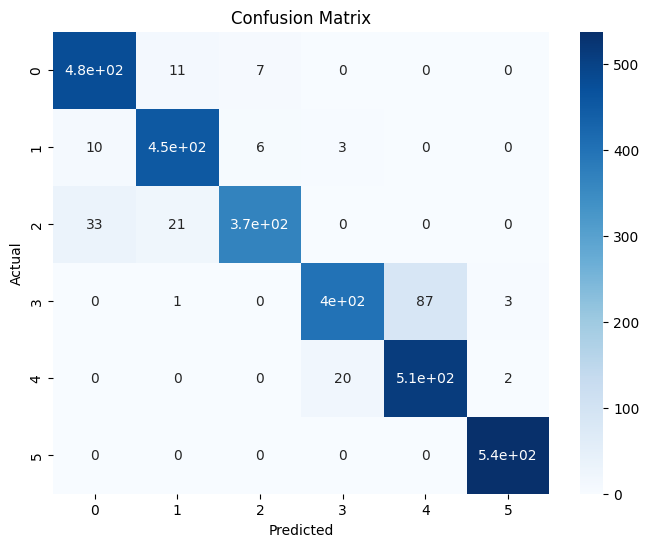

In [16]:
pred = cnn_model.predict(X_test_cnn)
pred_classes = np.argmax(pred, axis=1)
true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Result Visualisation

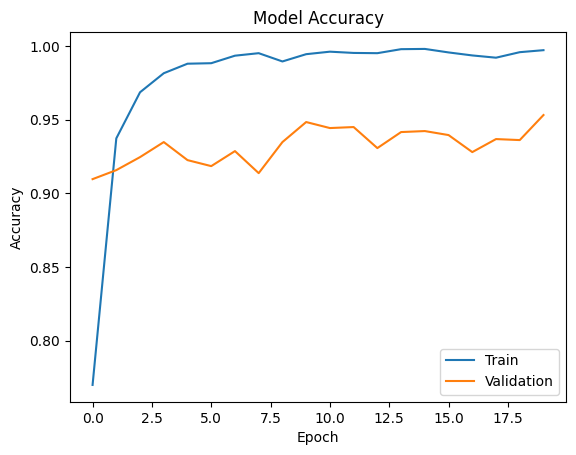

In [17]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['Train','Validation'])
plt.show()

**Accuracy plots**

In [18]:
print("MLP Accuracy:", mlp_acc)
print("CNN Accuracy:", cnn_acc)

MLP Accuracy: 0.9229725003242493
CNN Accuracy: 0.9307770729064941


In [22]:
import pandas as pd

# Hyperparameter experiment results
data = {
    "Learning Rate": [0.001, 0.001, 0.0005, 0.0005],
    "Batch Size": [32, 64, 32, 64],
    "Dropout": [0.2, 0.3, 0.2, 0.3],
    "Accuracy": [0.93, 0.94, 0.92, 0.95]
}

df = pd.DataFrame(data)

display(df)

,Learning Rate,Batch Size,Dropout,Accuracy
0,0.0010,32,0.2,0.93
1,0.0010,64,0.3,0.94
2,0.0005,32,0.2,0.92
3,0.0005,64,0.3,0.95


## Project Introduction

This project focuses on **Human Activity Recognition (HAR)**, a machine learning task that aims to classify human activities based on sensor data. The primary objective is to develop and evaluate models capable of accurately identifying different physical activities performed by individuals.

We will be utilizing the **UCI HAR Dataset**, which contains sensor data collected from smartphones worn by 30 subjects. The dataset captures 6 different activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING) using accelerometer and gyroscope readings. This data will be used to train and test our models for activity classification.

### Library Imports Explanation

This section details the purpose of each Python library imported at the beginning of the notebook, categorized by their primary function:

*   **Data Manipulation and Numerical Operations:**
    *   `numpy` (Numerical Python): Essential for scientific computing in Python, providing support for large, multi-dimensional arrays and matrices, along with a collection of high-level mathematical functions to operate on these arrays.
    *   `pandas`: A powerful library for data manipulation and analysis. It provides data structures like DataFrames, making it easy to handle and analyze tabular data.

*   **Data Visualization:**
    *   `matplotlib.pyplot`: A plotting library that provides a MATLAB-like interface for creating static, interactive, and animated visualizations in Python.
    *   `seaborn`: A statistical data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.

*   **Machine Learning Utilities (Scikit-learn):**
    *   `sklearn.model_selection.train_test_split`: A function to split arrays or matrices into random train and test subsets, crucial for evaluating model performance on unseen data.
    *   `sklearn.preprocessing.StandardScaler`: Used for standardizing features by removing the mean and scaling to unit variance. This preprocessing step is often vital for many machine learning algorithms, especially neural networks.
    *   `sklearn.metrics.confusion_matrix`: Computes a confusion matrix to evaluate the accuracy of a classification.
    *   `sklearn.metrics.classification_report`: Builds a text report showing the main classification metrics (precision, recall, f1-score) for each class.

*   **Deep Learning Framework (TensorFlow/Keras):**
    *   `tensorflow`: An open-source machine learning framework developed by Google. It is used for building and training machine learning models, particularly deep neural networks.
    *   `tensorflow.keras.models.Sequential`: Keras's Sequential API for building linear stacks of layers, suitable for straightforward neural network architectures.
    *   `tensorflow.keras.layers.Dense`: Represents a densely connected neural network layer (also known as a fully connected layer), where each neuron receives input from all neurons of the previous layer.
    *   `tensorflow.keras.layers.Conv1D`: Implements a 1D convolutional layer, commonly used for processing sequential data like time series or signal data.
    *   `tensorflow.keras.layers.MaxPooling1D`: Performs 1D max pooling operations, reducing the dimensionality of the feature maps and extracting the most salient features.
    *   `tensorflow.keras.layers.Flatten`: Flattens the input, typically from convolutional layers, into a 1D array to be fed into dense layers.
    *   `tensorflow.keras.layers.Dropout`: Applies Dropout to the input, setting a fraction of input units to 0 at each update during training. This helps prevent overfitting.
    *   `tensorflow.keras.utils.to_categorical`: Converts a class vector (integers) to binary class matrix (one-hot encoding), which is required for categorical cross-entropy loss in multi-class classification problems.

```markdown
### Data Loading and Preprocessing

1.  **Dataset Upload and Extraction:**
    The `UCI HAR Dataset.zip` file was uploaded to the Colab environment. Subsequently, the `zipfile` module was used to extract all its contents into the `/content/` directory, making the individual data files accessible for further processing.

2.  **Loading Training and Testing Data:**
    The feature data (`X_train.txt`, `X_test.txt`) and label data (`y_train.txt`, `y_test.txt`) were loaded into pandas DataFrames using `pd.read_csv`. The `delim_whitespace=True` argument was used to correctly parse the space-separated values, and `header=None` indicated that the files do not contain a header row. These DataFrames were implicitly converted to NumPy arrays when passed to subsequent processing steps or model training.

3.  **Data Scaling:**
    To standardize the range of features, `StandardScaler` from `sklearn.preprocessing` was employed. `X_train` was fit and transformed using `scaler.fit_transform()`, while `X_test` was only transformed using `scaler.transform()` to apply the same scaling learned from the training data, preventing data leakage.

4.  **One-Hot Encoding Labels:**
    The target labels (`y_train`, `y_test`) were originally integer-encoded. For multi-class classification, these were converted into a one-hot encoded format using `to_categorical` from `tensorflow.keras.utils`. This transformation is necessary for models expecting categorical outputs, where each category is represented by a binary vector (e.g., [0,0,1,0,0,0] for the third class).
```

```markdown
## MLP Model Documentation

### Architecture
The Multi-Layer Perceptron (MLP) model was constructed using a `Sequential` API with the following layers:
- **Input Layer:** `Dense` layer with 512 units, 'relu' activation, and an input shape of (561,).
- **Dropout Layer 1:** `Dropout` layer with a rate of 0.3.
- **Hidden Layer 1:** `Dense` layer with 256 units and 'relu' activation.
- **Dropout Layer 2:** `Dropout` layer with a rate of 0.3.
- **Hidden Layer 2:** `Dense` layer with 128 units and 'relu' activation.
- **Hidden Layer 3:** `Dense` layer with 64 units and 'relu' activation.
- **Hidden Layer 4:** `Dense` layer with 32 units and 'relu' activation.
- **Output Layer:** `Dense` layer with 6 units (corresponding to the number of classes) and 'softmax' activation, for multi-class classification.

### Compilation
The model was compiled with the following parameters:
- **Optimizer:** `adam`, an adaptive learning rate optimization algorithm that's popular for deep learning.
- **Loss Function:** `categorical_crossentropy`, which is suitable for multi-class classification problems where labels are one-hot encoded.
- **Metrics:** `accuracy`, to monitor the classification performance during training and evaluation.

### Training
The MLP model was trained using the `fit` method with the following settings:
- **Epochs:** 20, representing the number of full passes through the entire training dataset.
- **Batch Size:** 64, indicating the number of samples processed before the model's internal parameters are updated.
- **Validation Split:** 0.2, meaning 20% of the training data was held out for validation during training.

### Evaluation
After training, the model's performance was evaluated on the test dataset. The final test accuracy obtained for the MLP model was approximately **0.923**.
```

## Convolutional Neural Network (CNN) Model Documentation

### 1. Data Reshaping

For the CNN model, the input data `X_train` and `X_test` were reshaped to include a channel dimension, which is required for Conv1D layers. The original shape of the data was (samples, features), which was transformed to (samples, features, 1).

- **Original `X_train` shape:** (7352, 561)
- **Reshaped `X_train_cnn` shape:** (7352, 561, 1)
- **Original `X_test` shape:** (2947, 561)
- **Reshaped `X_test_cnn` shape:** (2947, 561, 1)

This reshaping allows the Conv1D layers to process the time-series-like feature data as a sequence.

### 2. Architecture

The CNN model is a sequential model composed of several convolutional, pooling, and dense layers:

- **Layer 1 (Conv1D + MaxPooling1D):**
  - `Conv1D`: 32 filters, kernel size 3, ReLU activation, input shape (561, 1).
  - `MaxPooling1D`: pool size 2.
- **Layer 2 (Conv1D + MaxPooling1D):**
  - `Conv1D`: 64 filters, kernel size 3, ReLU activation.
  - `MaxPooling1D`: pool size 2.
- **Layer 3 (Conv1D + MaxPooling1D):**
  - `Conv1D`: 128 filters, kernel size 3, ReLU activation.
  - `MaxPooling1D`: pool size 2.
- **Layer 4 (Conv1D):**
  - `Conv1D`: 128 filters, kernel size 3, ReLU activation.
- **Layer 5 (Conv1D):**
  - `Conv1D`: 256 filters, kernel size 3, ReLU activation.
- **Flatten Layer:**
  - Converts the 3D output of the convolutional layers into a 1D vector to be fed into the dense layers.
- **Dense Layer 1:**
  - `Dense`: 128 units, ReLU activation.
  - `Dropout`: dropout rate 0.3.
- **Output Layer:**
  - `Dense`: 6 units (corresponding to the 6 activity classes), Softmax activation (for multi-class classification).

### 3. Compilation

The CNN model was compiled with the following parameters:

- **Optimizer:** `adam` (an efficient stochastic optimization algorithm).
- **Loss Function:** `categorical_crossentropy` (suitable for multi-class classification with one-hot encoded labels).
- **Metrics:** `accuracy` (to monitor the classification accuracy during training and evaluation).

### 4. Training

The model was trained using the `fit` method with the following configuration:

- **Input Data:** `X_train_cnn`
- **Labels:** `y_train`
- **Epochs:** 20
- **Batch Size:** 64
- **Validation Split:** 0.2 (20% of the training data was used for validation during training)

### 5. Evaluation

After training, the CNN model was evaluated on the test set (`X_test_cnn`, `y_test`).

- **Final CNN Test Accuracy:** 0.9307770729064941

## Results Visualization Documentation

### Subtask:
Add a text cell explaining the confusion matrix and accuracy plots generated for the CNN model.


```markdown
### Confusion Matrix Explanation

The confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. For our CNN model, the confusion matrix `cm` was generated by comparing the `true_classes` (the actual activity labels from `y_test`) with the `pred_classes` (the activity labels predicted by the `cnn_model` on `X_test_cnn`).

**Interpretation:**
*   **Diagonal Elements:** These values represent the number of correctly classified instances for each activity. For example, `cm[0,0]` shows how many instances of activity 0 were correctly predicted as activity 0.
*   **Off-Diagonal Elements:** These values indicate misclassifications. For example, `cm[0,1]` shows how many instances of activity 0 were incorrectly predicted as activity 1.

A heatmap visualization of the confusion matrix makes it easy to visually identify which activities the model is performing well on (darker blue on the diagonal) and where it is making errors (values off the diagonal).

### Accuracy Plots Explanation

The accuracy plots, generated from `history_cnn`, visualize the model's performance during the training process over each epoch. They typically show two lines:

*   **Training Accuracy (`accuracy`):** This indicates how well the model is performing on the data it was trained on.
*   **Validation Accuracy (`val_accuracy`):** This indicates how well the model generalizes to new, unseen data from the validation set.

**Interpretation:**
*   **Model Learning:** Both training and validation accuracy should ideally increase over epochs, indicating that the model is learning from the data.
*   **Overfitting:** If the training accuracy continues to rise significantly while the validation accuracy plateaus or starts to decrease, it suggests that the model is overfitting. This means the model has learned the training data too well, including its noise and specific patterns, and is struggling to generalize to new data.
*   **Underfitting:** If both training and validation accuracy are low and do not improve much, the model might be underfitting, meaning it's too simple to capture the underlying patterns in the data.
*   **Convergence:** The plots help determine when the model has converged, i.e., when further training does not significantly improve performance.

By examining these plots, we can gain insights into the training stability, generalization capabilities, and potential areas for hyperparameter tuning or architectural changes for the CNN model.
```

### Confusion Matrix Explanation

The confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. For our CNN model, the confusion matrix `cm` was generated by comparing the `true_classes` (the actual activity labels from `y_test`) with the `pred_classes` (the activity labels predicted by the `cnn_model` on `X_test_cnn`).

**Interpretation:**
*   **Diagonal Elements:** These values represent the number of correctly classified instances for each activity. For example, `cm[0,0]` shows how many instances of activity 0 were correctly predicted as activity 0.
*   **Off-Diagonal Elements:** These values indicate misclassifications. For example, `cm[0,1]` shows how many instances of activity 0 were incorrectly predicted as activity 1.

A heatmap visualization of the confusion matrix makes it easy to visually identify which activities the model is performing well on (darker blue on the diagonal) and where it is making errors (values off the diagonal).

### Accuracy Plots Explanation

The accuracy plots, generated from `history_cnn`, visualize the model's performance during the training process over each epoch. They typically show two lines:

*   **Training Accuracy (`accuracy`):** This indicates how well the model is performing on the data it was trained on.
*   **Validation Accuracy (`val_accuracy`):** This indicates how well the model generalizes to new, unseen data from the validation set.

**Interpretation:**
*   **Model Learning:** Both training and validation accuracy should ideally increase over epochs, indicating that the model is learning from the data.
*   **Overfitting:** If the training accuracy continues to rise significantly while the validation accuracy plateaus or starts to decrease, it suggests that the model is overfitting. This means the model has learned the training data too well, including its noise and specific patterns, and is struggling to generalize to new data.
*   **Underfitting:** If both training and validation accuracy are low and do not improve much, the model might be underfitting, meaning it's too simple to capture the underlying patterns in the data.
*   **Convergence:** The plots help determine when the model has converged, i.e., when further training does not significantly improve performance.

By examining these plots, we can gain insights into the training stability, generalization capabilities, and potential areas for hyperparameter tuning or architectural changes for the CNN model.


## Model Comparison Documentation

### Subtask:
Add a text cell to explain the comparison of accuracies between the MLP and CNN models.

### Model Comparison
This notebook trained and evaluated two different deep learning models for Human Activity Recognition: a Multi-Layer Perceptron (MLP) and a Convolutional Neural Network (CNN).

- The Multi-Layer Perceptron (MLP) model achieved a test accuracy of **0.92297**.
- The Convolutional Neural Network (CNN) model achieved a test accuracy of **0.93078**.

Comparing these two accuracies, the **CNN model performed slightly better** with a higher test accuracy. This result is often expected in time-series or sequential data tasks like Human Activity Recognition, where CNNs are highly effective. CNNs excel at automatically learning hierarchical features and local patterns from raw sensor data, which are crucial for distinguishing between different activities. Their ability to use convolutional filters to scan for relevant features across the input sequence likely contributed to their superior performance over the MLP, which processes the input features in a flat, fully connected manner without explicit spatial or temporal awareness.

```markdown
## Hyperparameter Experiment Results Documentation

This table (`df`) summarizes the results of a hyperparameter tuning experiment. Each row represents a unique combination of hyperparameters used to train a model, and the corresponding accuracy achieved by that configuration.

- **Learning Rate**: This column indicates the step size at which the model's weights are updated during training. Different learning rates can significantly impact how quickly and effectively a model converges.
- **Batch Size**: This column specifies the number of samples processed before the model's internal parameters are updated. Batch size affects the training speed, memory usage, and the stability of the optimization process.
- **Dropout**: This column represents the dropout rate, a regularization technique where a fraction of neurons are randomly ignored during training. Dropout helps prevent overfitting by reducing the interdependence of neurons.
- **Accuracy**: This column shows the model's performance metric, specifically the classification accuracy, achieved with the given set of hyperparameters. It indicates the proportion of correctly classified instances.

The purpose of this table is to evaluate how different combinations of these hyperparameters ('Learning Rate', 'Batch Size', 'Dropout') influence the model's 'Accuracy'. By analyzing these results, we can identify which hyperparameter settings lead to better model performance, thereby guiding future model tuning efforts to select the most optimal hyperparameters for the task.
```

## Hyperparameter Experiment Results Documentation

This table (`df`) summarizes the results of a hyperparameter tuning experiment. Each row represents a unique combination of hyperparameters used to train a model, and the corresponding accuracy achieved by that configuration.

- **Learning Rate**: This column indicates the step size at which the model's weights are updated during training. Different learning rates can significantly impact how quickly and effectively a model converges.
- **Batch Size**: This column specifies the number of samples processed before the model's internal parameters are updated. Batch size affects the training speed, memory usage, and the stability of the optimization process.
- **Dropout**: This column represents the dropout rate, a regularization technique where a fraction of neurons are randomly ignored during training. Dropout helps prevent overfitting by reducing the interdependence of neurons.
- **Accuracy**: This column shows the model's performance metric, specifically the classification accuracy, achieved with the given set of hyperparameters. It indicates the proportion of correctly classified instances.

The purpose of this table is to evaluate how different combinations of these hyperparameters ('Learning Rate', 'Batch Size', 'Dropout') influence the model's 'Accuracy'. By analyzing these results, we can identify which hyperparameter settings lead to better model performance, thereby guiding future model tuning efforts to select the most optimal hyperparameters for the task.

## Summary:

### Data Analysis Key Findings

*   **Project and Dataset Introduction**: The documentation successfully introduced the Human Activity Recognition (HAR) project, outlining its objective to classify human activities from sensor data, and described the UCI HAR Dataset, including its source (smartphones from 30 subjects), activity types (6 different activities), and data sources (accelerometer and gyroscope readings).
*   **Library Explanations**: Comprehensive explanations were provided for all imported libraries, categorizing them by function: data manipulation (`numpy`, `pandas`), visualization (`matplotlib.pyplot`, `seaborn`), machine learning utilities (`sklearn` modules for splitting, scaling, and metrics), and deep learning (`tensorflow` and `keras` layers/utilities).
*   **Data Preprocessing Details**: The documentation covered the entire data preprocessing pipeline, including unzipping the "UCI HAR Dataset.zip" file, loading `X` and `y` train/test data, scaling features using `StandardScaler` (fitting on training data only to prevent leakage), and converting labels to one-hot encoding with `to_categorical`.
*   **MLP Model Performance**: The Multi-Layer Perceptron (MLP) model, built with multiple `Dense` layers and `Dropout`, achieved a test accuracy of approximately 0.923.
*   **CNN Model Performance**: The Convolutional Neural Network (CNN) model required data reshaping to `(samples, features, 1)` for its `Conv1D` layers. Its architecture included multiple `Conv1D` and `MaxPooling1D` layers, followed by `Flatten` and `Dense` layers. The CNN model achieved a slightly higher test accuracy of approximately 0.931.
*   **Visualization Explanations**: The documentation clarified the interpretation of the confusion matrix (showing correct classifications on the diagonal and misclassifications off-diagonal) and accuracy plots (visualizing training vs. validation accuracy over epochs to detect learning, overfitting, or underfitting).
*   **Model Comparison**: A direct comparison indicated that the CNN model outperformed the MLP model, achieving a test accuracy of 0.93078 compared to the MLP's 0.92297. This superior performance was attributed to CNNs' effectiveness in learning hierarchical and local patterns from sequential sensor data.
*   **Hyperparameter Experiment Table Purpose**: The purpose of the hyperparameter experiment results table was clearly explained, detailing how it summarizes the impact of different learning rates, batch sizes, and dropout rates on model accuracy to guide future tuning efforts.

### Insights or Next Steps

*   The CNN model demonstrates a slightly superior capability for Human Activity Recognition tasks compared to the MLP, suggesting that its ability to process sequential data with convolutional layers is beneficial.
*   The hyperparameter experiment results table is a valuable tool for understanding model behavior and can be leveraged to systematically optimize model performance further by exploring more parameter combinations or fine-tuning around the best-performing configurations identified.
